## 1. imports and getting data

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
db = sqlite3.connect("../data/checking-logs.sqlite")

test_uids = pd.read_sql("SELECT DISTINCT uid FROM test WHERE uid LIKE 'user_%';", db)["uid"]

checker = pd.read_sql(
    "SELECT uid, status, numTrials, labname, timestamp "
    "FROM checker "
    "WHERE uid LIKE 'user_%' AND status='ready' AND labname!='project1';",
    db, parse_dates=["timestamp"]
)

pageviews = pd.read_sql(
    "SELECT uid, datetime FROM pageviews WHERE uid LIKE 'user_%';",
    db, parse_dates=["datetime"]
)

deadlines = pd.read_sql("SELECT labs AS labname, deadlines FROM deadlines;", db)

## 2. Preprocessing

In [3]:
deadlines["deadline"] = pd.to_datetime(deadlines["deadlines"], unit="s")

first = checker[checker["numTrials"] == 1][["uid", "labname", "timestamp"]]
fc = first.merge(deadlines[["labname", "deadline"]], on="labname", how="left")
fc["diff_h"] = (fc["timestamp"] - fc["deadline"]).dt.total_seconds() / 3600
avg_diff = fc.groupby("uid")["diff_h"].mean().rename("avg_diff")
avg_diff.head()

uid
user_0           NaN
user_1    -65.119644
user_10   -75.242310
user_11    -2.884175
user_12   -89.450688
Name: avg_diff, dtype: float64

In [4]:
pv = pageviews[pageviews["uid"].isin(test_uids)].groupby("uid").size().rename("pageviews")
cm = checker.groupby("uid").size().rename("num_commits")

result = pd.DataFrame(index=test_uids).join([avg_diff, pv, cm]).fillna(0)
result[["pageviews", "num_commits"]] = result[["pageviews", "num_commits"]].astype(int)

result.head()

,avg_diff,pageviews,num_commits
uid,,,
user_1,-65.119644,28,35
user_10,-75.242310,89,13
user_14,-159.568696,143,33
user_17,-62.207513,47,29
user_18,-6.367907,3,4


## 3. Scatter graph

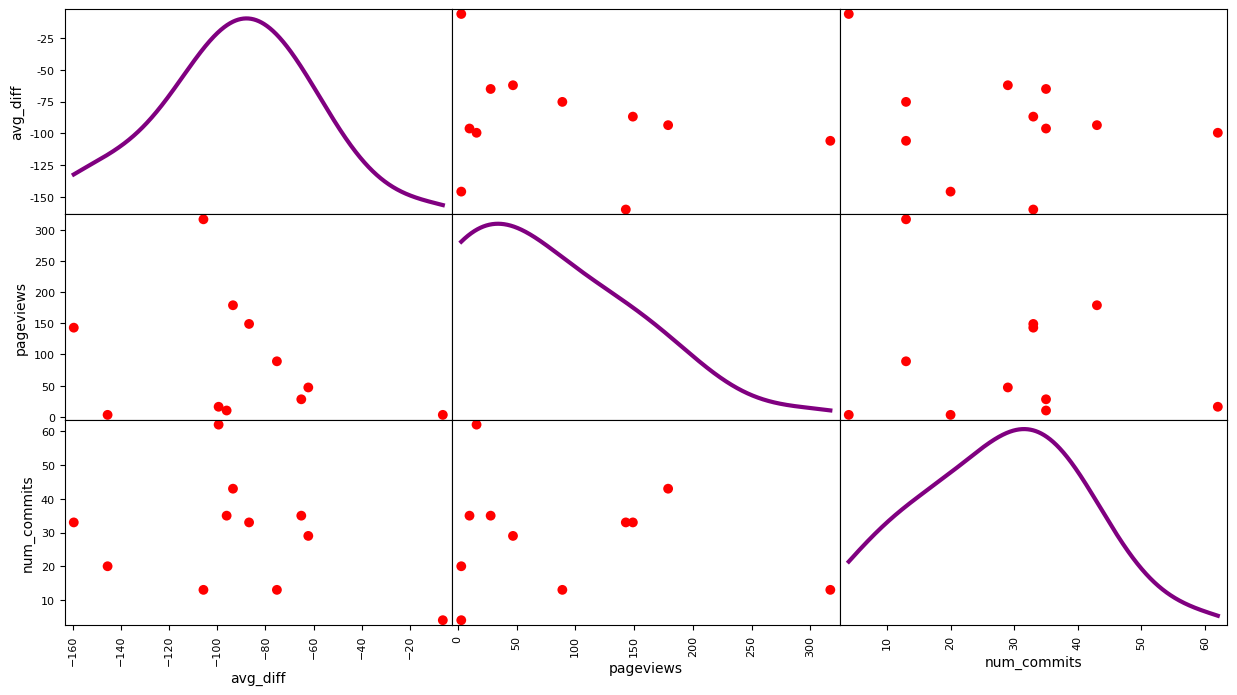

In [5]:

axes = scatter_matrix(
    result[["avg_diff", "pageviews", "num_commits"]],
    figsize = (15, 8),
    diagonal="kde",
    s = 200,
    color = "red",
    alpha = 1.0,
    density_kwds={"linewidth": 3, "color": "purple"})


## 4. Questions
"Can we say that if a user has a low number of pageviews, then they likely have a low number of commits?" 
- No.

"Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline?"
-  No.

"Can we say that there are many users with a low number of commits and a few with a high number of commits?"
-  Yes.

"Can we say that there are many users with a small average difference and a few with a large average difference?" 
- No.

## 5. Closing

In [6]:
db.close()